In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
df = pd.read_csv("/Users/deepakkumar/Desktop/Stocks/ADANIPORTS.csv")

In [3]:
df.dropna(subset=['Date ', 'close '], inplace = True)
df['tdate'] = pd.to_datetime(df["Date "])

In [12]:
df['tclose'] = pd.to_numeric(df['close '].str.replace(',','')).apply(np.floor)
df['tvolume'] = pd.to_numeric(df['VOLUME '].str.replace(',','')).apply(np.floor)
df['tvol'] = df['tvolume']/ df['tvolume'].min()

In [5]:
df['tclose'].describe()

count     248.000000
mean     1323.681452
std       143.861830
min      1053.000000
25%      1190.750000
50%      1347.500000
75%      1452.250000
max      1590.000000
Name: tclose, dtype: float64

In [6]:
# Fair value is defined median value of most repeating value range
def fair_value(price_list):
    start = int(price_list.min())
    end = int(price_list.max())
    window = int(price_list.std())
    counts = price_list.value_counts(bins=range(start, end, window), sort=False)
    fair_value = counts.idxmax().mid
    print("Most repeating value is around ", fair_value)
    return fair_value

In [7]:
fair_value(df['tclose'])

Most repeating value is around  1410.5


1410.5

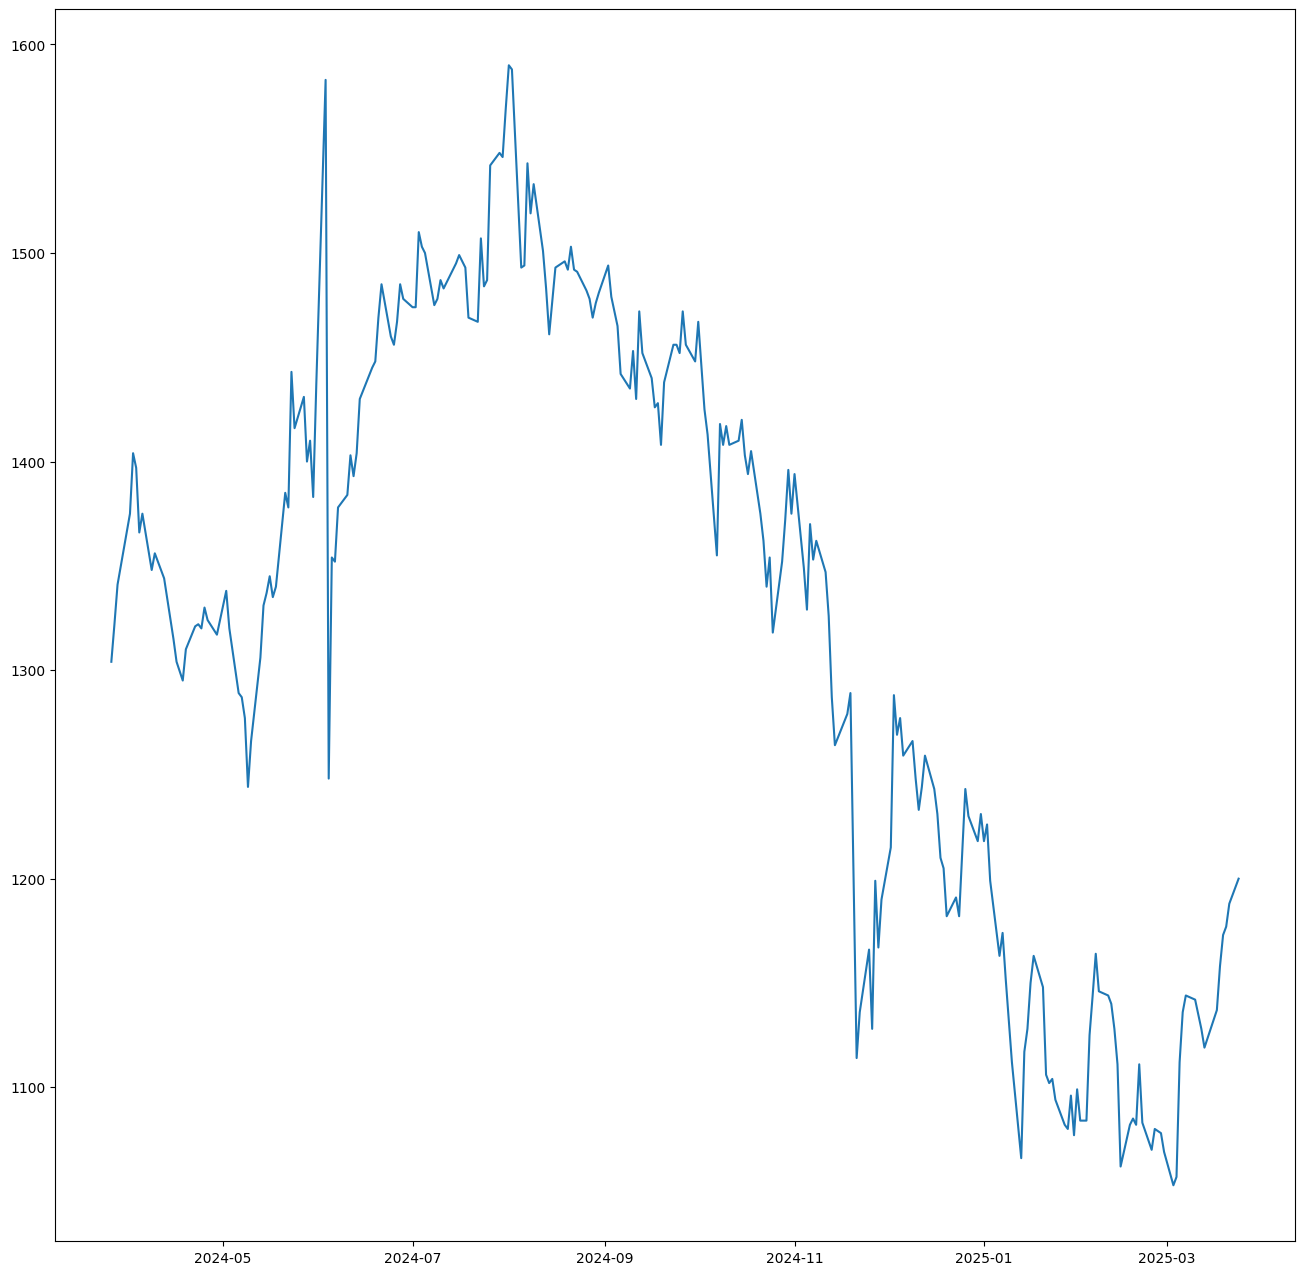

In [8]:
plt.figure(figsize=(16,16))
plt.plot(df['tdate'], df['tclose'])

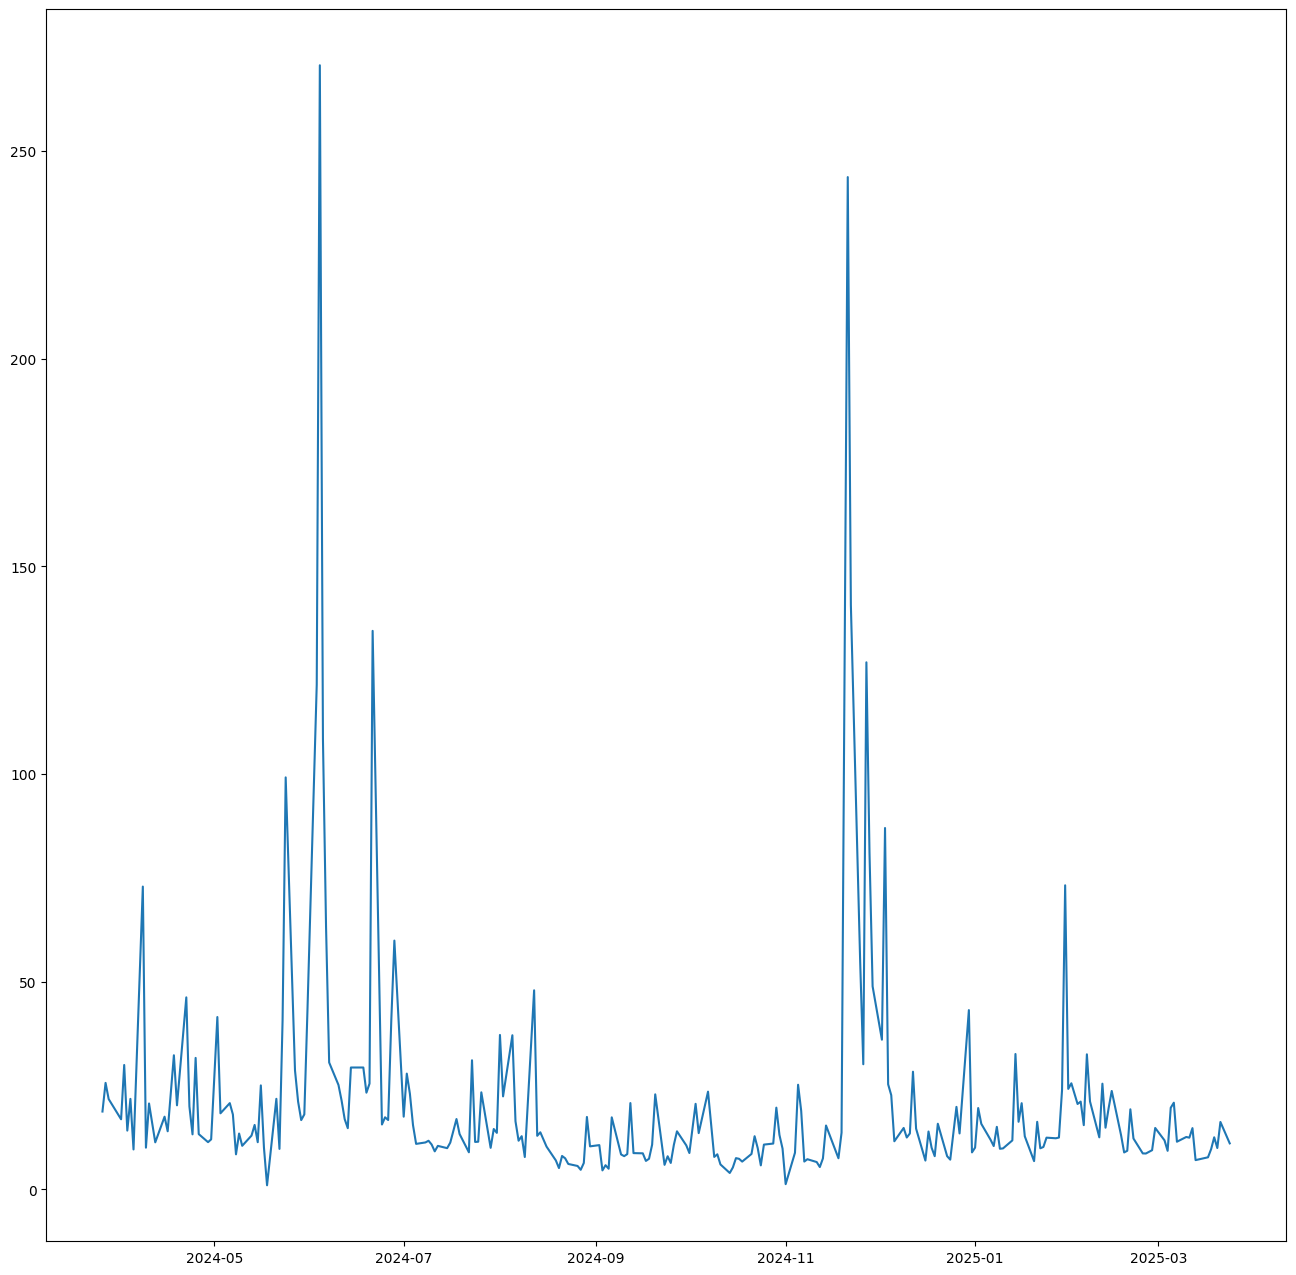

In [13]:
plt.figure(figsize=(16,16))
plt.plot(df['tdate'], df['tvol'])